In [11]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec

In [12]:
project='incTel'
ed='run4/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')

varG='gridfac05'

dsG05=xr.open_dataset(str(location) +  str(varG) + '.nc')

varG='gridfac01'

dsG01=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacC05 = dsG05.HFacC

hfa05 = np.ma.masked_values(hFacC05, 0)
mask05 = np.ma.getmask(hfa05)

hFacC01 = dsG01.HFacC

hfa01 = np.ma.masked_values(hFacC01, 0)
mask01 = np.ma.getmask(hfa01)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [13]:
start=np.where(ds.T/(60*60*24*360)>1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=2)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [14]:
params = {'font.size': 10,
          'figure.figsize': (10, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [15]:
closS=20 #int(len(dsG.Y)*0.4)
closE=np.where(dsG.Y>=130000)[0][0]#np.where(dsG.Y>=130000)[0][0] #np.where(dsG.Y>=260000)[0][0]
depS=np.where(dsG.Z>=-400)[0][-1]
depE=np.where(dsG.Z>=-700)[0][-1]

In [16]:
def BottomConc(vel, hfac, nz, ny,nx,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((ny,nx))
    BottomInd = np.argmax(hfac[::-1,:,5]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for i in range(ny): 
        for k in range(nx): 
            BotVel[i,k] = vel[int(BottomInd[i]),i,k] 
            
    
    return (BotVel,BottomInd.astype(int))


In [7]:
nz=len(dsG.Z)
ny=len(dsG.Y)
nx=len(dsG.X)

hfacBot,BottomInd=BottomConc(hFacC[:,:,:].values,hFacC[:,:,:].values , nz, ny,nx,1)
hfacBot05,BottomInd05=BottomConc(hFacC05[:,:,:].values,hFacC05[:,:,:].values , nz, ny,nx,1)
hfacBot01,BottomInd01=BottomConc(hFacC01[:,:,:].values,hFacC01[:,:,:].values , nz, ny,nx,1)



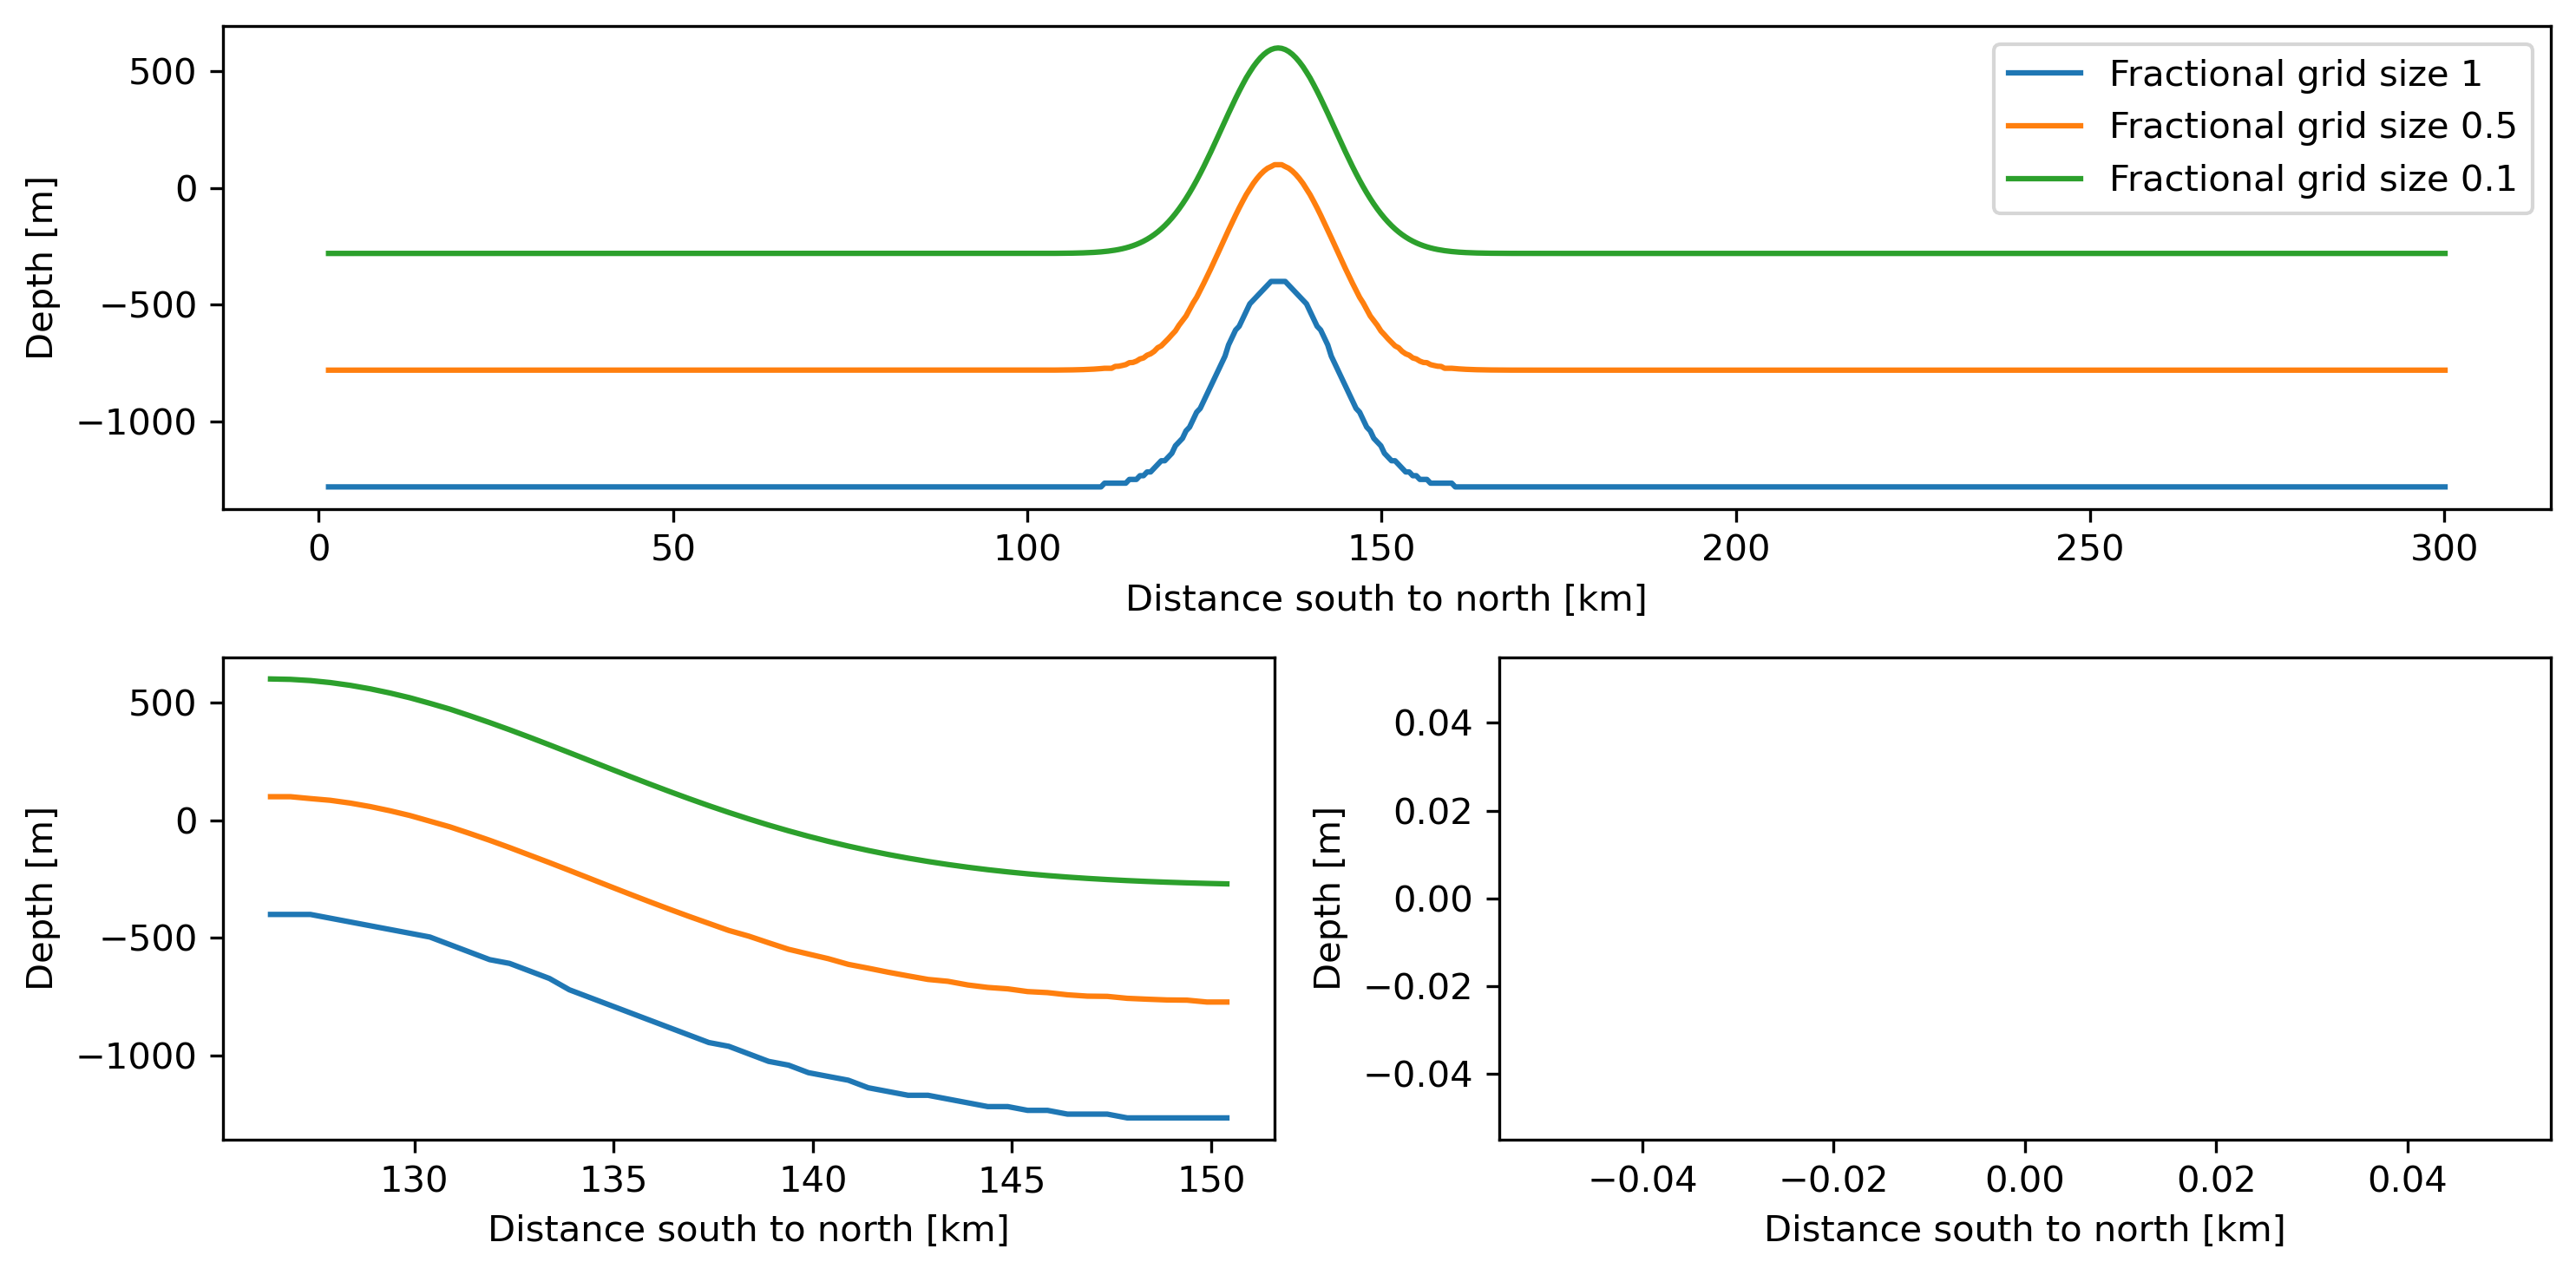

In [18]:
indX=np.arange(4,6,1) #-2#1 #int(nx/2)
end=-1

lines=np.arange(umbral1,umbralEnd1,int((umbralEnd1-umbral1)/5))
fig=plt.figure()
gs = GridSpec(nrows=2, ncols=2)

ax = fig.add_subplot(gs[0, :])

ax.plot(dsG.Y/1000,-dsG.Depth[:,20],label='Fractional grid size 1')
ax.plot(dsG05.Y/1000,-dsG05.Depth[:,20]+500,label='Fractional grid size 0.5')
ax.plot(dsG01.Y/1000,-dsG01.Depth[:,20]+1000,label='Fractional grid size 0.1')

ax.legend()
ax.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')    
ax = fig.add_subplot(gs[1, :1])
ax.plot(dsG.Y[umbral1:umbralEnd1]/1000,-dsG.Depth[umbral:umbralEnd,20],label='Fractional grid size 1')
ax.plot(dsG05.Y[umbral1:umbralEnd1]/1000,-dsG05.Depth[umbral:umbralEnd,20]+500,label='Fractional grid size 0.5')
ax.plot(dsG01.Y[umbral1:umbralEnd1]/1000,-dsG01.Depth[umbral:umbralEnd,20]+1000,label='Fractional grid size 0.1')


ax.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')    

ax = fig.add_subplot(gs[1, 1:])
ax.plot(dsG.Y[umbral2:umbralEnd2]/1000,-dsG.Depth[umbral2:umbralEnd2,20],label='Fractional grid size 1')
ax.plot(dsG05.Y[umbral2:umbralEnd2]/1000,-dsG05.Depth[umbral2:umbralEnd2,20]+500,label='Fractional grid size 0.5')
ax.plot(dsG01.Y[umbral2:umbralEnd2]/1000,-dsG01.Depth[umbral2:umbralEnd2,20]+1000,label='Fractional grid size 0.1')

ax.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')  
fig.tight_layout()

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'CompHfacs.png', bbox_inches='tight')